In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import bitsandbytes as bnb
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
import evaluate
from peft import LoraConfig, get_peft_model, TaskType
from collections import Counter
from transformers import BitsAndBytesConfig
from collections import Counter

from dotenv import load_dotenv
import os
load_dotenv()
YOUR_HF_TOKEN = os.getenv("YOUR_HF_TOKEN")

/home/bistreamt/Desktop/master/research 3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def combine_text(row):
    # Collect all existing description parts in order
    desc_parts = [row.get(f"case_description_{i}", "") for i in range(1, 9) if row.get(f"case_description_{i}")]
    # Collect all existing justification parts in order
    just_parts = [row.get(f"justification_{i}", "") for i in range(1, 5) if row.get(f"justification_{i}")]
    
    # Prioritize description by putting it first
    return " ".join(desc_parts + just_parts)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
with open("data/supreme-court-data.json", 'r', encoding='utf-8') as f:
    data = json.load(f)

if isinstance(data, list):
    labels = [item["label"] for item in data if "label" in item]
    
    label_counts = Counter(labels)
    
    print("Number of samples per label:")
    for label, count in sorted(label_counts.items()):
        print(f"{label:12} : {count:4d} samples")
    
    print(f"\nTotal samples in Supreme Court Data: {len(data)}")

Number of samples per label:
admis        :  396 samples
inadmisibil  :  588 samples
respins      :  416 samples

Total samples in Supreme Court Data: 1400


In [5]:
# Define your mapping
path = "data/supreme-court-data.json"
label_map = {
    "respins": 0,
    "admis": 1,
    "inadmisibil": 2,
}

def prepare_dataset(json_file_path, num_labels):
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    if num_labels == 2:
        data = [item for item in data if item['label'] != 'inadmisibil']

    formatted_data = []
    for entry in data:
        # Combine description (1-8) and justification (1-4)
        desc = " ".join([entry.get(f"case_description_{i}", "") for i in range(1, 9)]).strip()
        just = " ".join([entry.get(f"justification_{i}", "") for i in range(1, 5)]).strip()
        
        formatted_data.append({
            "text": f"{desc} {just}", # Description prioritized by order
            "label": label_map[entry["label"]]
        })
    
    # Filter out the top 10% of entries with longest text
    text_lengths = [len(entry["text"].split()) for entry in formatted_data]
    threshold = np.percentile(text_lengths, 94)
    formatted_data = [entry for entry, length in zip(formatted_data, text_lengths) if length <= threshold]
    return Dataset.from_list(formatted_data)

raw = prepare_dataset(path, 3)

In [6]:
model_name = "dumitrescustefan/bert-base-romanian-cased-v1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=4096)
    # return tokenizer(examples["text"])

tokenized = raw.map(tokenize_function, batched=True)


Map: 100%|██████████| 1316/1316 [00:00<00:00, 1597.69 examples/s]


In [7]:
model_name = "readerbench/RoGPT2-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=4096)
    # return tokenizer(examples["text"])

tokenized_2 = raw.map(tokenize_function, batched=True)


Map: 100%|██████████| 1316/1316 [00:00<00:00, 1818.88 examples/s]


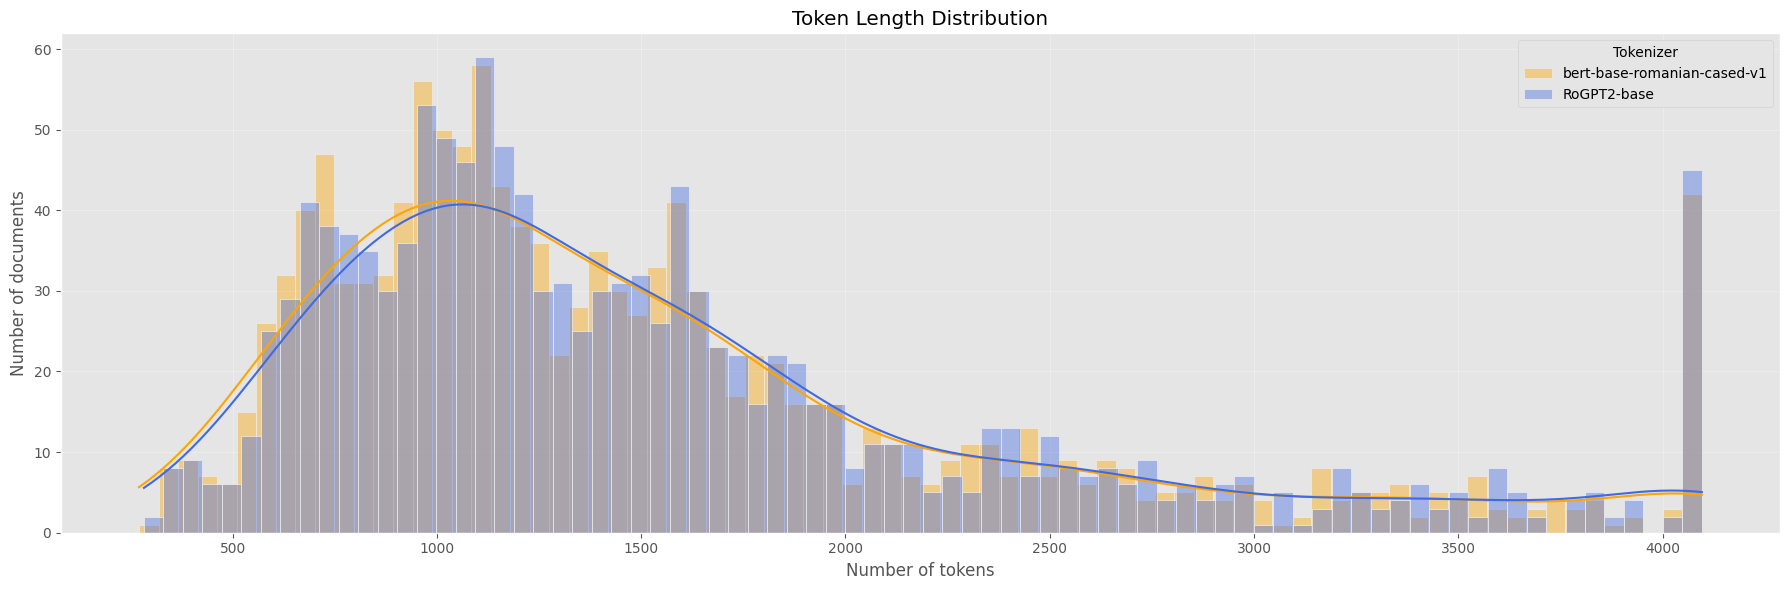

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

lengths = []
lengths_2 = []

# Extract token lengths
lengths = [len(sample["input_ids"]) for sample in tokenized]
lengths_2 = [len(sample["input_ids"]) for sample in tokenized_2]

# Plot style
plt.style.use("ggplot")
plt.figure(figsize=(18, 6))

# Histogram + KDE for train
sns.histplot(
    lengths,
    bins=80,
    kde=True,
    stat="count",
    color="orange",
    alpha=0.4,
    label="bert-base-romanian-cased-v1"
)

# Histogram + KDE for validation
sns.histplot(
    lengths_2,
    bins=80,
    kde=True,
    stat="count",
    color="royalblue",
    alpha=0.4,
    label="RoGPT2-base"
)

# Labels and formatting
plt.xlabel("Number of tokens")
plt.ylabel("Number of documents")
plt.title("Token Length Distribution")
plt.legend(title="Tokenizer")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "token_length_distribution_supmd.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
with open("data/regional-court-data.json", 'r', encoding='utf-8') as f:
    data = json.load(f)

if isinstance(data, list):
    labels = [item["label"] for item in data if "label" in item]
    
    label_counts = Counter(labels)
    
    print("Number of samples per label:")
    for label, count in sorted(label_counts.items()):
        print(f"{label:12} : {count:4d} samples")
    
    print(f"\nTotal samples in Regional Court Data: {len(data)}")

Number of samples per label:
nevinovat    : 3626 samples
vinovat      : 5244 samples

Total samples in Regional Court Data: 8870


In [10]:
# Define your mapping
path = "data/regional-court-data.json"
label_map = {
    "vinovat": 0,
    "nevinovat": 1
}

def prepare_dataset(json_file_path):
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    formatted_data = []
    for entry in data:
        # Combine description (1-8) and justification (1-4)
        desc = " ".join([entry.get(f"case_description_{i}", "") for i in range(1, 9)]).strip()
        # just = " ".join([entry.get(f"justification_{i}", "") for i in range(1, 5)]).strip()
        
        formatted_data.append({
            "text": f"{desc}", # Description prioritized by order
            "label": label_map[entry["label"]]
        })
    
    # Filter out the top 10% of entries with longest text
    text_lengths = [len(entry["text"].split()) for entry in formatted_data]
    threshold_max = np.percentile(text_lengths, 77)
    threshold_min = np.percentile(text_lengths, 3)
    formatted_data = [entry for entry, length in zip(formatted_data, text_lengths) if threshold_min <= length <= threshold_max]
    return Dataset.from_list(formatted_data)

raw = prepare_dataset(path)

In [11]:
model_name = "dumitrescustefan/bert-base-romanian-cased-v1"

tokenizer = AutoTokenizer.from_pretrained(model_name)
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=4096)
    # return tokenizer(examples["text"])

tokenized = raw.map(tokenize_function, batched=True)


Map: 100%|██████████| 6567/6567 [00:04<00:00, 1495.83 examples/s]


In [12]:
model_name = "readerbench/RoGPT2-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=4096)
    # return tokenizer(examples["text"])

tokenized_2 = raw.map(tokenize_function, batched=True)


Map: 100%|██████████| 6567/6567 [00:04<00:00, 1474.29 examples/s]


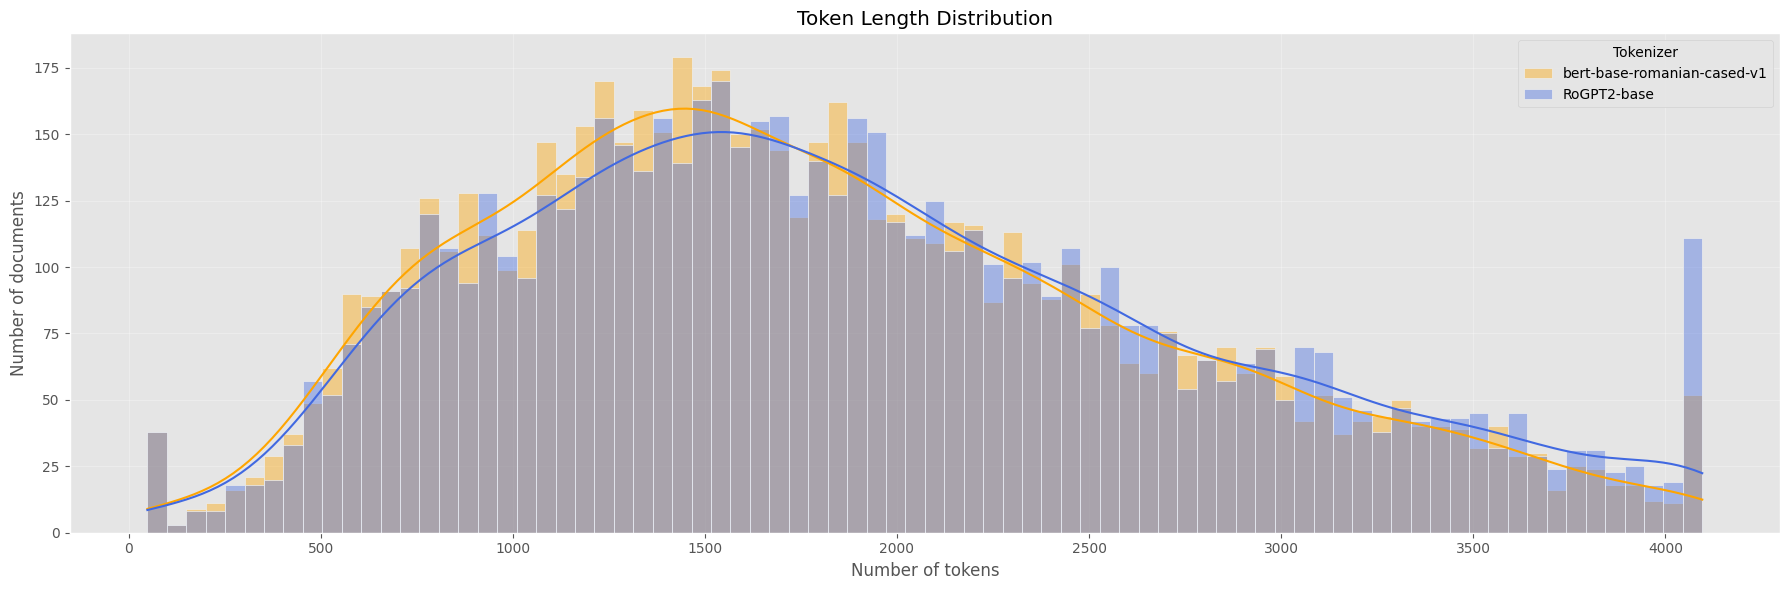

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

lengths = []
lengths_2 = []

# Extract token lengths
lengths = [len(sample["input_ids"]) for sample in tokenized]
lengths_2 = [len(sample["input_ids"]) for sample in tokenized_2]

# Plot style
plt.style.use("ggplot")
plt.figure(figsize=(18, 6))

# Histogram + KDE for train
sns.histplot(
    lengths,
    bins=80,
    kde=True,
    stat="count",
    color="orange",
    alpha=0.4,
    label="bert-base-romanian-cased-v1"
)

# Histogram + KDE for validation
sns.histplot(
    lengths_2,
    bins=80,
    kde=True,
    stat="count",
    color="royalblue",
    alpha=0.4,
    label="RoGPT2-base"
)

# Labels and formatting
plt.xlabel("Number of tokens")
plt.ylabel("Number of documents")
plt.title("Token Length Distribution")
plt.legend(title="Tokenizer")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "token_length_distribution_regmd.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()